# 使用 OpenVINO™ 轉換 YOLO26 模型並進行物件偵測推論

2026/04/20, Jack OmniXRI 整理製作

將 Yolo26 PyTorch 預訓練模型轉換成 IR 格式(*.bin + *.xml)，再進行物件偵測模型進行推論

原始資料來源：https://colab.research.google.com/github/openvinotoolkit/openvino_notebooks/blob/latest/notebooks/yolov26-optimization/yolov26-object-detection.ipynb#scrollTo=30dd6b4b


# 1.取得並安裝必要套件

In [1]:
import platform

if platform.system() == "Darwin":
    %pip install -q "numpy<2.0.0"


%pip install -qU "openvino>=2026.0.0" "nncf>=3.0.0"
%pip install -q "torch==2.10" torchvision --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "ultralytics==8.4.22" tqdm opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.6/805.6 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.0 MB/s eta 0:00:00


# 2.下載並安裝 OpenVINO 必要函式庫

In [2]:
from pathlib import Path
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

from notebook_utils import download_file, VideoPlayer, device_widget, quantization_widget

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("yolov26-object-detection.ipynb")

# 3.下載待測試影像至虛擬機磁碟

可自行提供網路圖像連結。

In [3]:
# Download a test sample
IMAGE_PATH = Path("./data/coco_bike.jpg")

if not IMAGE_PATH.exists():
    download_file(
        url="https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco_bike.jpg",
        filename=IMAGE_PATH.name,
        directory=IMAGE_PATH.parent,
    )

coco_bike.jpg:   0%|          | 0.00/182k [00:00<?, ?B/s]

# 4.選擇 Yolo26 模型

可選擇不同大小的模型，包括 "yolo26n", "yolo26s", "yolo26m", "yolo26l", "yolo26x"， 預設為 "yolo26n"

In [4]:
import ipywidgets as widgets

model_id = ["yolo26n", "yolo26s", "yolo26m", "yolo26l", "yolo26x"]

model_name = widgets.Dropdown(options=model_id, value=model_id[0], description="Model")

model_name

Dropdown(description='Model', options=('yolo26n', 'yolo26s', 'yolo26m', 'yolo26l', 'yolo26x'), value='yolo26n'…

# 5.指定物件偵測推論模型及裝置

使用 YOLO PyTorch 預訓練模型進行推論

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/data/coco_bike.jpg: 480x640 2 bicycles, 2 cars, 1 dog, 331.8ms
Speed: 13.9ms preprocess, 331.8ms inference, 4.7ms postprocess per image at shape (1, 3, 480, 640)


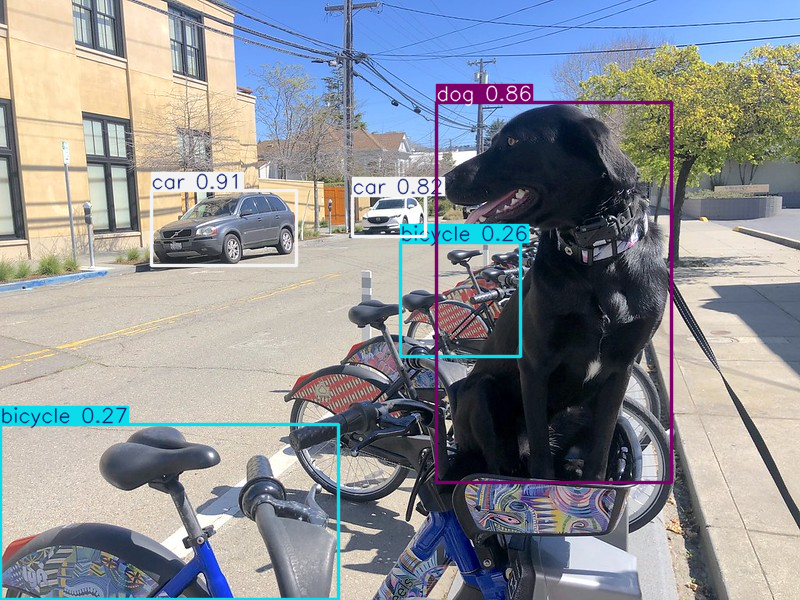

In [5]:
from PIL import Image
from ultralytics import YOLO

DET_MODEL_NAME = model_name.value

det_model = YOLO(f"{DET_MODEL_NAME}.pt")
det_model.to("cpu")
label_map = det_model.model.names

res = det_model(IMAGE_PATH)
Image.fromarray(res[0].plot()[:, :, ::-1])


# 6.將模型轉換為 OpenVINO IR

將 PyTorch 轉成 IR格式(*.bin + *.xml) 並存放在虛擬機 /模型名_openvino_model 路徑下

**half:** 以 FP16 精度計算的輸出權重，以縮小模型尺寸並加快推論速度

**dynamic:** 保留原始的預處理行為（自適應 LetterBox 填充），並產生最接近 PyTorch 模型的結果。dynamic=False 使用固定的 640×640 輸入形狀——這是 NPU 部署所必需的，可能提升吞吐量，但因填充不同，可能會稍微影響偵測結果

**end2end:** YOLO26 必要。 輸出無 NMS 的端對端模型。YOLO26 使用單一的 one2one 偵測頭，因此 end2end=False 會在匯出時產生 KeyError

**注意：** 與較舊的 YOLO 版本（v8、v11）同時支援 end2end=True 和 end2end=False 不同，YOLO26 架構上不依賴 NMS，且僅支援 end2end=True。


In [6]:
# object detection model
det_model_path = Path(f"{DET_MODEL_NAME}_openvino_model/{DET_MODEL_NAME}.xml")

if not det_model_path.exists():
    det_model.export(format="openvino", dynamic=False, half=True, end2end=True)

Ultralytics 8.4.22 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'yolo26n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.3 MB)

OpenVINO: starting export with openvino 2026.1.0-21367-63e31528c62-releases/2026/1...
OpenVINO: export success ✅ 5.1s, saved as 'yolo26n_openvino_model/' (5.1 MB)

Export complete (5.6s)
Results saved to /content
Predict:         yolo predict task=detect model=yolo26n_openvino_model imgsz=640 half
Validate:        yolo val task=detect model=yolo26n_openvino_model imgsz=640 data=/home/lq/codes/ultralytics/ultralytics/cfg/datasets/coco.yaml half 
Visualize:       https://netron.app


# 7.選擇推理裝置

在 Colab 中使用 OpenVINO 裝置只能選 CPU(XEON) 或 Auto，預設為 Auto。

In [7]:
device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

# 8.載入 YOLO IR 格式模型及待測影像進行推論

使用已轉換好 IR 格式 YOLO 模型進行推論

Loading yolo26n_openvino_model for OpenVINO inference...
WARNING ⚠️ OpenVINO device 'AUTO' not available. Using 'AUTO' instead.
Loading yolo26n_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

image 1/1 /content/data/coco_bike.jpg: 640x640 1 bicycle, 2 cars, 1 dog, 226.1ms
Speed: 6.1ms preprocess, 226.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


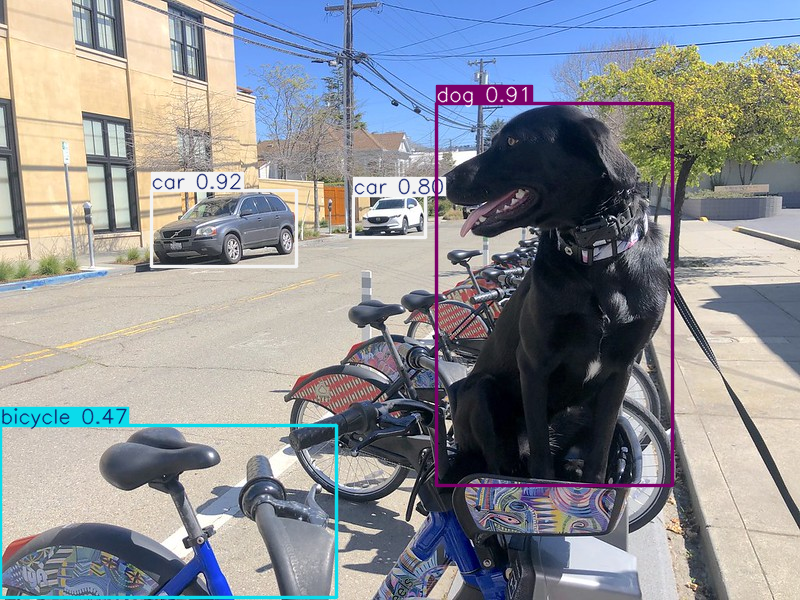

In [8]:
det_model = YOLO(det_model_path.parent, task="detect")

res = det_model(IMAGE_PATH, device=f"intel:{device.value.lower()}")
Image.fromarray(res[0].plot()[:, :, ::-1])